# Wine Quality Classification - Step 2: Model Training

**Objective:** Train and compare multiple ML models to predict wine quality.

**Models:** Logistic Regression, Random Forest, SVM, XGBoost

**Output:** Best model saved as `best_model.pkl`

## 1. Load and Prepare Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# Load data
data_path = Path('data') / 'winequality-combined.csv'
df = pd.read_csv(data_path)

# Create binary target
df['quality_label'] = (df['quality'] >= 6).astype(int)

# Get features and target
feature_cols = [col for col in df.columns if col not in ['quality', 'quality_label', 'wine_type']]
X = df[feature_cols]
y = df['quality_label']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")
print(f"Class balance: {y.mean():.1%} good wines")

## 2. Split and Scale Data

In [3]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train class distribution: {y_train.value_counts().to_dict()}")
print(f"Test class distribution: {y_test.value_counts().to_dict()}")

# Scale features (important for SVM and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData scaled: ✓")

Training set: (5197, 11)
Test set: (1300, 11)
Train class distribution: {1: 3290, 0: 1907}
Test class distribution: {1: 823, 0: 477}

Data scaled: ✓


## 3. Train Models

In [4]:
# Dictionary to store models and results
models = {}
results = {}

# 1. Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr
print("✓ Done")

# 2. Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
models['Random Forest'] = rf
print("✓ Done")

# 3. Support Vector Machine
print("Training SVM...")
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
models['SVM'] = svm
print("✓ Done")

# 4. XGBoost
print("Training XGBoost...")
xgb = XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
models['XGBoost'] = xgb
print("✓ Done")

print("\nAll models trained successfully!")

Training Logistic Regression...
✓ Done
Training Random Forest...
✓ Done
Training SVM...
✓ Done
Training XGBoost...
✓ Done

All models trained successfully!
✓ Done
Training XGBoost...
✓ Done

All models trained successfully!


## 4. Evaluate Models

In [5]:
# Function to evaluate model
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Probabilities for ROC-AUC
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    results[model_name] = {
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'precision': precision_score(y_test, y_test_pred),
        'recall': recall_score(y_test, y_test_pred),
        'f1': f1_score(y_test, y_test_pred),
        'roc_auc': roc_auc_score(y_test, y_test_proba)
    }

# Evaluate each model
for model_name, model in models.items():
    if model_name == 'Logistic Regression':
        evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, model_name)
    elif model_name == 'SVM':
        evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, model_name)
    else:
        evaluate_model(model, X_train, X_test, y_train, y_test, model_name)

# Display results
results_df = pd.DataFrame(results).round(4)
print("Model Performance Comparison:")
print(results_df)

Model Performance Comparison:
                Logistic Regression  Random Forest     SVM  XGBoost
train_accuracy               0.7420         1.0000  0.7931   0.9865
test_accuracy                0.7338         0.8377  0.7785   0.8162
precision                    0.7624         0.8525  0.7930   0.8380
recall                       0.8420         0.8991  0.8797   0.8797
f1                           0.8002         0.8752  0.8341   0.8583
roc_auc                      0.8045         0.9044  0.8394   0.8843


## 5. Select Best Model

In [ ]:
SCALED_MODELS = {'Logistic Regression', 'SVM'}

# Find best model by F1 score
best_model_name = results_df.loc['f1'].idxmax()
best_f1 = results_df.loc['f1', best_model_name]
best_accuracy = results_df.loc['test_accuracy', best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {best_accuracy:.4f}")
print(f"F1 Score: {best_f1:.4f}")

best_model = models[best_model_name]
needs_scaling = best_model_name in SCALED_MODELS

# Save to models/ folder
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

joblib.dump(best_model, models_dir / 'best_model.pkl')
joblib.dump({
    'model_name': best_model_name,
    'needs_scaling': needs_scaling,
    'feature_columns': feature_cols
}, models_dir / 'model_metadata.pkl')

if needs_scaling:
    joblib.dump(scaler, models_dir / 'scaler.pkl')
    print(f"✓ Scaler saved        → models/scaler.pkl  (required for {best_model_name})")
else:
    print(f"✓ Scaler not saved    ({best_model_name} does not require scaling)")

print(f"✓ Model saved         → models/best_model.pkl")
print(f"✓ Metadata saved      → models/model_metadata.pkl")

## 6. Feature Importance (Top Model)


Top 10 Most Important Features (Random Forest):
                 feature  importance
10               alcohol    0.158356
1       volatile acidity    0.114046
7                density    0.107085
4              chlorides    0.084638
6   total sulfur dioxide    0.082930
5    free sulfur dioxide    0.080926
3         residual sugar    0.080596
9              sulphates    0.078377
2            citric acid    0.076277
8                     pH    0.070615


<Figure size 1000x600 with 0 Axes>

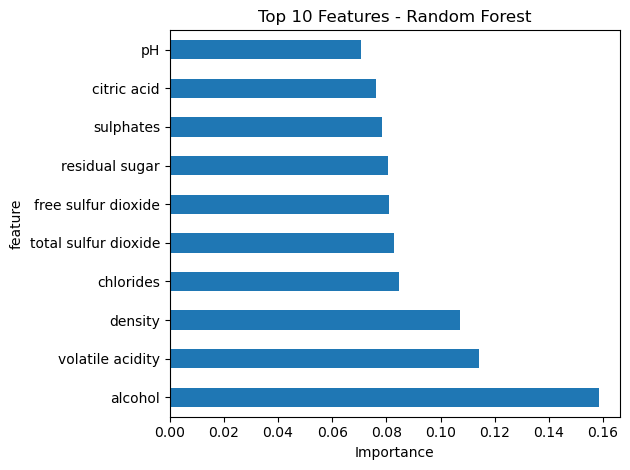

In [7]:
# Feature importance (if model supports it)
if best_model_name in ['Random Forest', 'XGBoost']:
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print(f"\nTop 10 Most Important Features ({best_model_name}):")
    print(feature_importance_df.head(10))
    
    # Visualize
    plt.figure(figsize=(10, 6))
    feature_importance_df.head(10).plot(x='feature', y='importance', kind='barh', legend=False)
    plt.title(f'Top 10 Features - {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f"\n{best_model_name} doesn't provide feature importance.")

## 7. Confusion Matrix

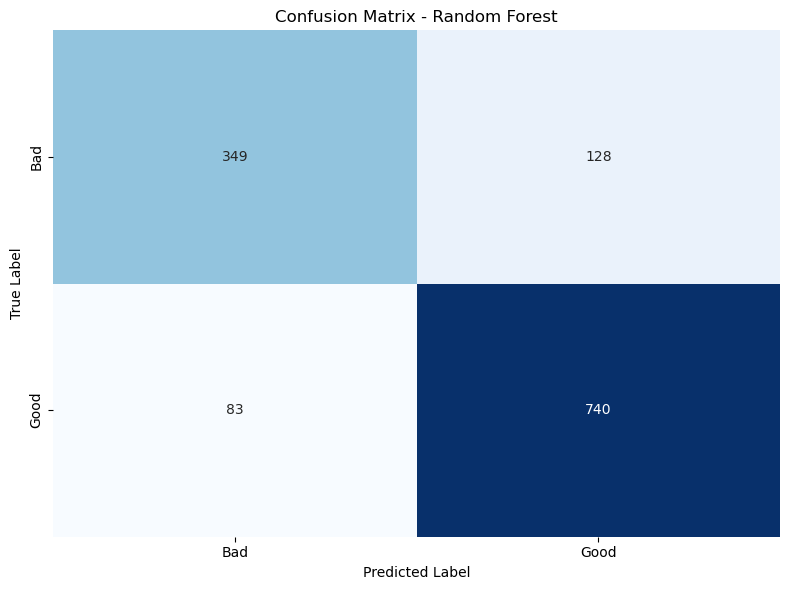

True Negatives: 349
False Positives: 128
False Negatives: 83
True Positives: 740


In [8]:
# Get predictions from best model
if best_model_name in ['Logistic Regression', 'SVM']:
    y_pred = best_model.predict(X_test_scaled)
else:
    y_pred = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Bad', 'Good'],
            yticklabels=['Bad', 'Good'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"True Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## 8. Summary

In [ ]:
print("\n" + "="*60)
print("MODEL TRAINING SUMMARY")
print("="*60)
print(f"\nDataset: {len(df)} wines")
print(f"Features: {len(feature_cols)}")
print(f"Train/Test Split: 80/20")
print(f"\nModels Trained: {', '.join(models.keys())}")
print(f"\nBest Model: {best_model_name}")
print(f"Test Accuracy: {best_accuracy:.2%}")
print(f"F1 Score: {best_f1:.4f}")
print(f"ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")
print(f"Requires Scaling: {needs_scaling}")
print(f"\nSaved to models/:")
print(f"  - best_model.pkl")
print(f"  - model_metadata.pkl")
if needs_scaling:
    print(f"  - scaler.pkl")
print("\n✓ Ready for Streamlit app!")
print("="*60)